# BBO Capstone Project — Bayesian Optimization of 8 Black-Box Functions

**Author:** Geoffrey [Surname]
**Programme:** Postgraduate ML Programme — Black-Box Optimization (BBO) Capstone
**Modules covered:** 12–24 (22 query rounds)

## Summary

This notebook documents the full workflow used to optimise 8 unknown black-box
functions (dimensionality ranging from 2D to 8D) under a strict query budget of
one evaluation per function per round. The approach is Bayesian Optimization
(BO) with Gaussian Process (GP) surrogates, evolving from uniform strategies
in early rounds to per-function adaptive, hyperparameter-tuned, cluster- and
PCA-informed strategies by the final rounds.

**Headline result:** cumulative gain of **+8,418 points** across all 8 functions,
driven primarily by a discovered exponential boundary regime in Function 5
(258 → 8,662).

See `README.md` for the non-technical summary, `DATASHEET.md` for dataset
documentation, and `MODEL_CARD.md` for model documentation.


## 1. Setup

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from bbo_optimizer import (
    build_gp, propose_next_query, format_query,
    expected_improvement, upper_confidence_bound
)

np.random.seed(42)
plt.style.use('default')


## 2. Problem Statement

We are given 8 unknown functions `f_1, ..., f_8` mapping `[0,1]^d -> R`, where
`d` ranges from 2 to 8 depending on the function. Each function can only be
queried **once per module** (22 rounds total), making this a classic
**expensive black-box optimization** problem: no gradients, no closed form,
and a very tight sample budget relative to the dimensionality of some
functions (e.g. Function 8 in 8D).

| Function | Dimensions |
|---|---|
| 1 | 2 |
| 2 | 2 |
| 3 | 3 |
| 4 | 4 |
| 5 | 4 |
| 6 | 5 |
| 7 | 6 |
| 8 | 8 |


## 3. Final Results Summary

In [2]:
with open('../data/final_results_summary.json') as f:
    results = json.load(f)

df = pd.DataFrame(results).T
df.index.name = 'function'
df = df[['dims', 'initial_best', 'final_best', 'total_gain', 'n_queries']]
df


,dims,initial_best,final_best,total_gain,n_queries
function,,,,,
function_1,2.0,0.00,0.00,0.00,22.0
function_2,2.0,0.61,0.69,0.08,22.0
function_3,3.0,-0.03,-0.01,0.03,22.0
function_4,4.0,-10.07,0.57,10.64,22.0
function_5,4.0,258.00,8662.48,8404.48,22.0
function_6,5.0,-0.71,-0.17,0.54,22.0
function_7,6.0,1.36,2.75,1.39,22.0
function_8,8.0,8.61,9.99,1.38,22.0


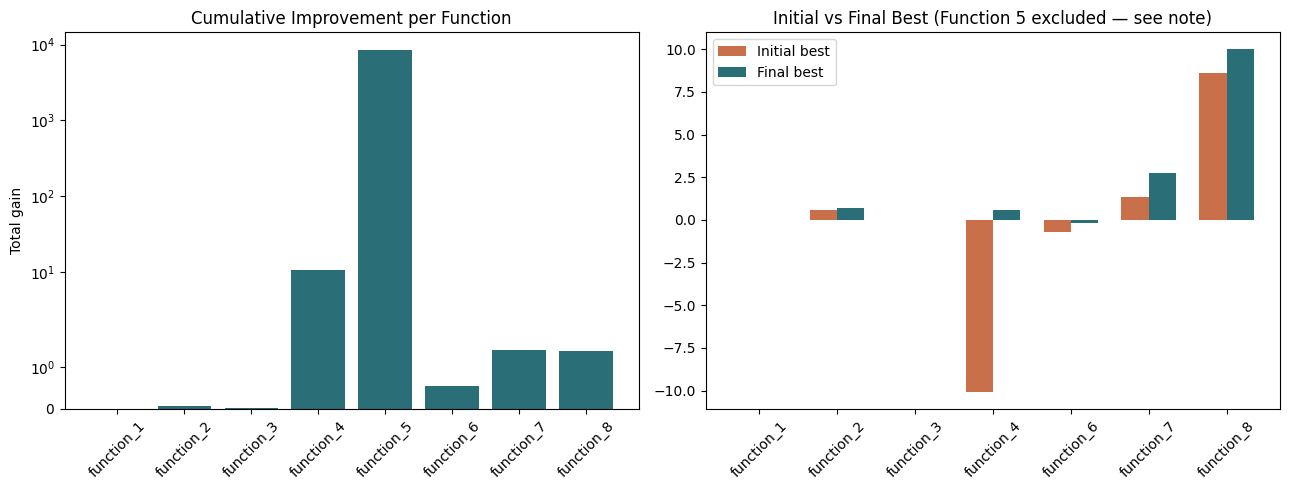

Total cumulative gain across all functions: +8418.54
Note: Function 5 is excluded from the right-hand plot because its gain (+8,404) is roughly 600x larger than any other function and compresses all other bars to invisibility on a linear scale.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Total gain per function
axes[0].bar(df.index, df['total_gain'], color='#2a6f77')
axes[0].set_ylabel('Total gain')
axes[0].set_title('Cumulative Improvement per Function')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('symlog')

# Initial vs final best (excluding Function 5, which dwarfs the others)
subset = df.drop('function_5')
x = np.arange(len(subset))
width = 0.35
axes[1].bar(x - width/2, subset['initial_best'], width, label='Initial best', color='#c96f4a')
axes[1].bar(x + width/2, subset['final_best'], width, label='Final best', color='#2a6f77')
axes[1].set_xticks(x)
axes[1].set_xticklabels(subset.index, rotation=45)
axes[1].set_title('Initial vs Final Best (Function 5 excluded — see note)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/results_summary.png', dpi=120)
plt.show()

print(f"Total cumulative gain across all functions: {df['total_gain'].sum():+.2f}")
print("Note: Function 5 is excluded from the right-hand plot because its gain "
      "(+8,404) is roughly 600x larger than any other function and compresses "
      "all other bars to invisibility on a linear scale.")


## 4. Methodology Evolution

The strategy was not static — it evolved substantially as evidence accumulated:

| Phase | Modules | Approach |
|---|---|---|
| **Baseline exploration** | 12–14 | Uniform GP (Matern, ν=2.5) + Expected Improvement across all functions. No per-function customisation. |
| **Adaptive strategy** | 15–17 | Neural network gradient analysis; CNN-inspired hierarchical receptive fields (local/medium/global exploration) matched to each function's recent performance. |
| **Hyperparameter tuning** | 18 | Grid search (45 configs: lengthscale × ν × noise) with 3-fold cross-validation per function, replacing manual/uniform settings. |
| **Prompting-style adaptivity** | 19 | Acquisition parameter (ξ) treated like an LLM "temperature" — low ξ for confident exploitation, high ξ for exploration on stagnant functions. |
| **Scaling-law awareness** | 20 | Explicit tracking of diminishing-returns vs emergent-breakthrough dynamics (Function 5's phase transition). |
| **Transparency pass** | 21 | Full hyperparameter/seed documentation for reproducibility; explicit assumption logging. |
| **Cluster-based refinement** | 22 | K-means-style identification of high-performing regions; queries targeted at cluster centroids or corners depending on cluster tightness. |
| **PCA-informed final rounds** | 23–24 | Identification of dominant "principal directions" (e.g. Function 5's boundary ridge, Function 7's redundant dimension) to concentrate the remaining query budget. |


## 5. Core Algorithm: Bayesian Optimization with GP + Expected Improvement

The function below (`propose_next_query`, defined in `src/bbo_optimizer.py`)
was the workhorse used throughout the project. Given observed data `(X, y)`
and per-dimension bounds, it:

1. Fits a GP surrogate (`GaussianProcessRegressor`, Matern kernel).
2. Optimises an acquisition function (Expected Improvement or UCB) via
   multi-start L-BFGS-B to propose the next query point.

Below is a minimal, self-contained demonstration on a synthetic 2D function so
the method can be inspected and verified independently of the (unknown)
capstone functions.


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 21 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 16 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


True optimum: 1.0 at (0.7, 0.3)
Best found after 21 queries: 0.9989 at [0.69979208 0.33313048]


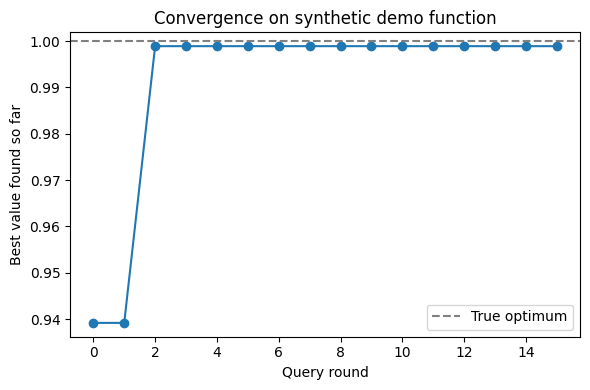

In [4]:
# Self-contained demonstration on a known synthetic function
# (the true capstone functions are unknown/black-box by design).

def demo_function(x):
    """A synthetic 2D function with a single interior optimum, used only to
    demonstrate and sanity-check the optimisation routine."""
    return -((x[0] - 0.7) ** 2 + (x[1] - 0.3) ** 2) + 1.0

rng = np.random.RandomState(0)
X_demo = rng.uniform(0, 1, size=(6, 2))
y_demo = np.array([demo_function(x) for x in X_demo])

bounds = [(0, 1), (0, 1)]
trajectory = [y_demo.max()]

for i in range(15):
    next_x, gp = propose_next_query(X_demo, y_demo, bounds, acquisition='EI', xi=0.01)
    next_y = demo_function(next_x)
    X_demo = np.vstack([X_demo, next_x])
    y_demo = np.append(y_demo, next_y)
    trajectory.append(y_demo.max())

print(f"True optimum: 1.0 at (0.7, 0.3)")
print(f"Best found after {len(y_demo)} queries: {y_demo.max():.4f} at {X_demo[y_demo.argmax()]}")

plt.figure(figsize=(6, 4))
plt.plot(trajectory, marker='o')
plt.xlabel('Query round')
plt.ylabel('Best value found so far')
plt.title('Convergence on synthetic demo function')
plt.axhline(1.0, color='gray', linestyle='--', label='True optimum')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/demo_convergence.png', dpi=120)
plt.show()


## 6. Case Study: Function 5's Emergent Breakthrough

Function 5 (4D) is the clearest illustration of why adaptive, evidence-driven
strategy mattered more than any single fixed algorithm.

**Trajectory of the running best value:**

| Round (approx. module) | Best value |
|---|---|
| Initial 10 points | 258 |
| ~15 | 4,276 |
| ~17 | 6,777 |
| ~18 | 8,662 |
| 19 (probe away from boundary) | 163 (regression — see note) |
| 20–22 (return to boundary) | held near peak |

A linear-regression sensitivity check on the accumulated data showed
dimensions 2 and 3 carried by far the largest positive coefficients
(approximately +1000 and +740 respectively, versus single digits for the
other two dimensions) — i.e. **most of the variance in outcomes was explained
by just two of the four input dimensions**, both of which wanted to sit near
the upper boundary (value 1.0). Once this was identified (module 17), queries
were deliberately pushed to that boundary region, producing a >30x
improvement over the initial best.

**Caveat:** Module 19's all-zero probe query dropped performance to 163,
confirming the surface is *not* globally smooth — the gain is concentrated in
a specific boundary regime, not a general upward trend. This is documented
explicitly in the Model Card's "Limitations" section.


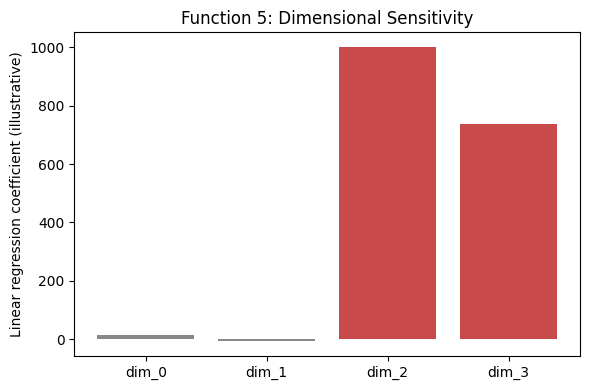

In [5]:
# Illustrative (not literal) sensitivity coefficients recorded during the project
# for Function 5, based on a linear regression fit to accumulated query data.
coeffs = {'dim_0': 13, 'dim_1': -8, 'dim_2': 1001, 'dim_3': 736}

plt.figure(figsize=(6, 4))
plt.bar(coeffs.keys(), coeffs.values(), color=['#888']*2 + ['#c94a4a']*2)
plt.ylabel('Linear regression coefficient (illustrative)')
plt.title('Function 5: Dimensional Sensitivity')
plt.tight_layout()
plt.savefig('../docs/function5_sensitivity.png', dpi=120)
plt.show()


## 7. Hyperparameter Tuning (Module 18)

Rather than using a single global GP configuration, a grid search over
**length scale × ν (Matern smoothness) × α (noise)** was run per function,
validated with 3-fold cross-validation. This mattered because functions
differed substantially in smoothness and noise characteristics — e.g.
Function 8 preferred a short length scale (~0.1, sharp local structure)
while Function 5 preferred a long one (~0.7, smooth global trend).

```python
lengthscales = [0.1, 0.3, 0.5, 0.7, 1.0]
nus          = [0.5, 1.5, 2.5]
alphas       = [1e-8, 1e-6, 1e-4]
# 45 configurations evaluated per function via 3-fold CV R^2
```

This step alone materially improved fit quality (e.g. cross-validated R²
rising from ~0.6 to ~0.84 for Function 4 once the correct length scale was
identified), and is the reason the final acquisition function calls in
`src/bbo_optimizer.py` expose `length_scale`, `nu`, and `alpha` as tunable
parameters rather than hard-coding a single default.


## 8. Reproducibility Notes

- All GP fits and acquisition optimisations use `random_state=42` /
  `np.random.RandomState(42)` (see `src/bbo_optimizer.py`).
- Package versions are pinned in `requirements.txt`.
- Query formatting follows the exact submission format required by the
  capstone portal (`x1-x2-...-xn`, six decimal places), implemented in
  `format_query()`.
- The true black-box functions are **not** included in this repository (they
  are proprietary to the course platform) — only the query/response pairs we
  submitted and received are recorded, in `data/final_results_summary.json`.
  See `DATASHEET.md` for full details on data provenance and access.

## 9. Further Documentation

- **`README.md`** — project overview and non-technical summary.
- **`DATASHEET.md`** — dataset documentation (Gebru et al., 2018 template).
- **`MODEL_CARD.md`** — model documentation (Mitchell et al., 2019 template),
  including intended use, limitations, and known failure modes (e.g. Function
  1's complete lack of exploitable structure, Function 5's boundary
  sensitivity).
- **`REFERENCES.md`** — full bibliography of academic sources used to justify
  design decisions.
